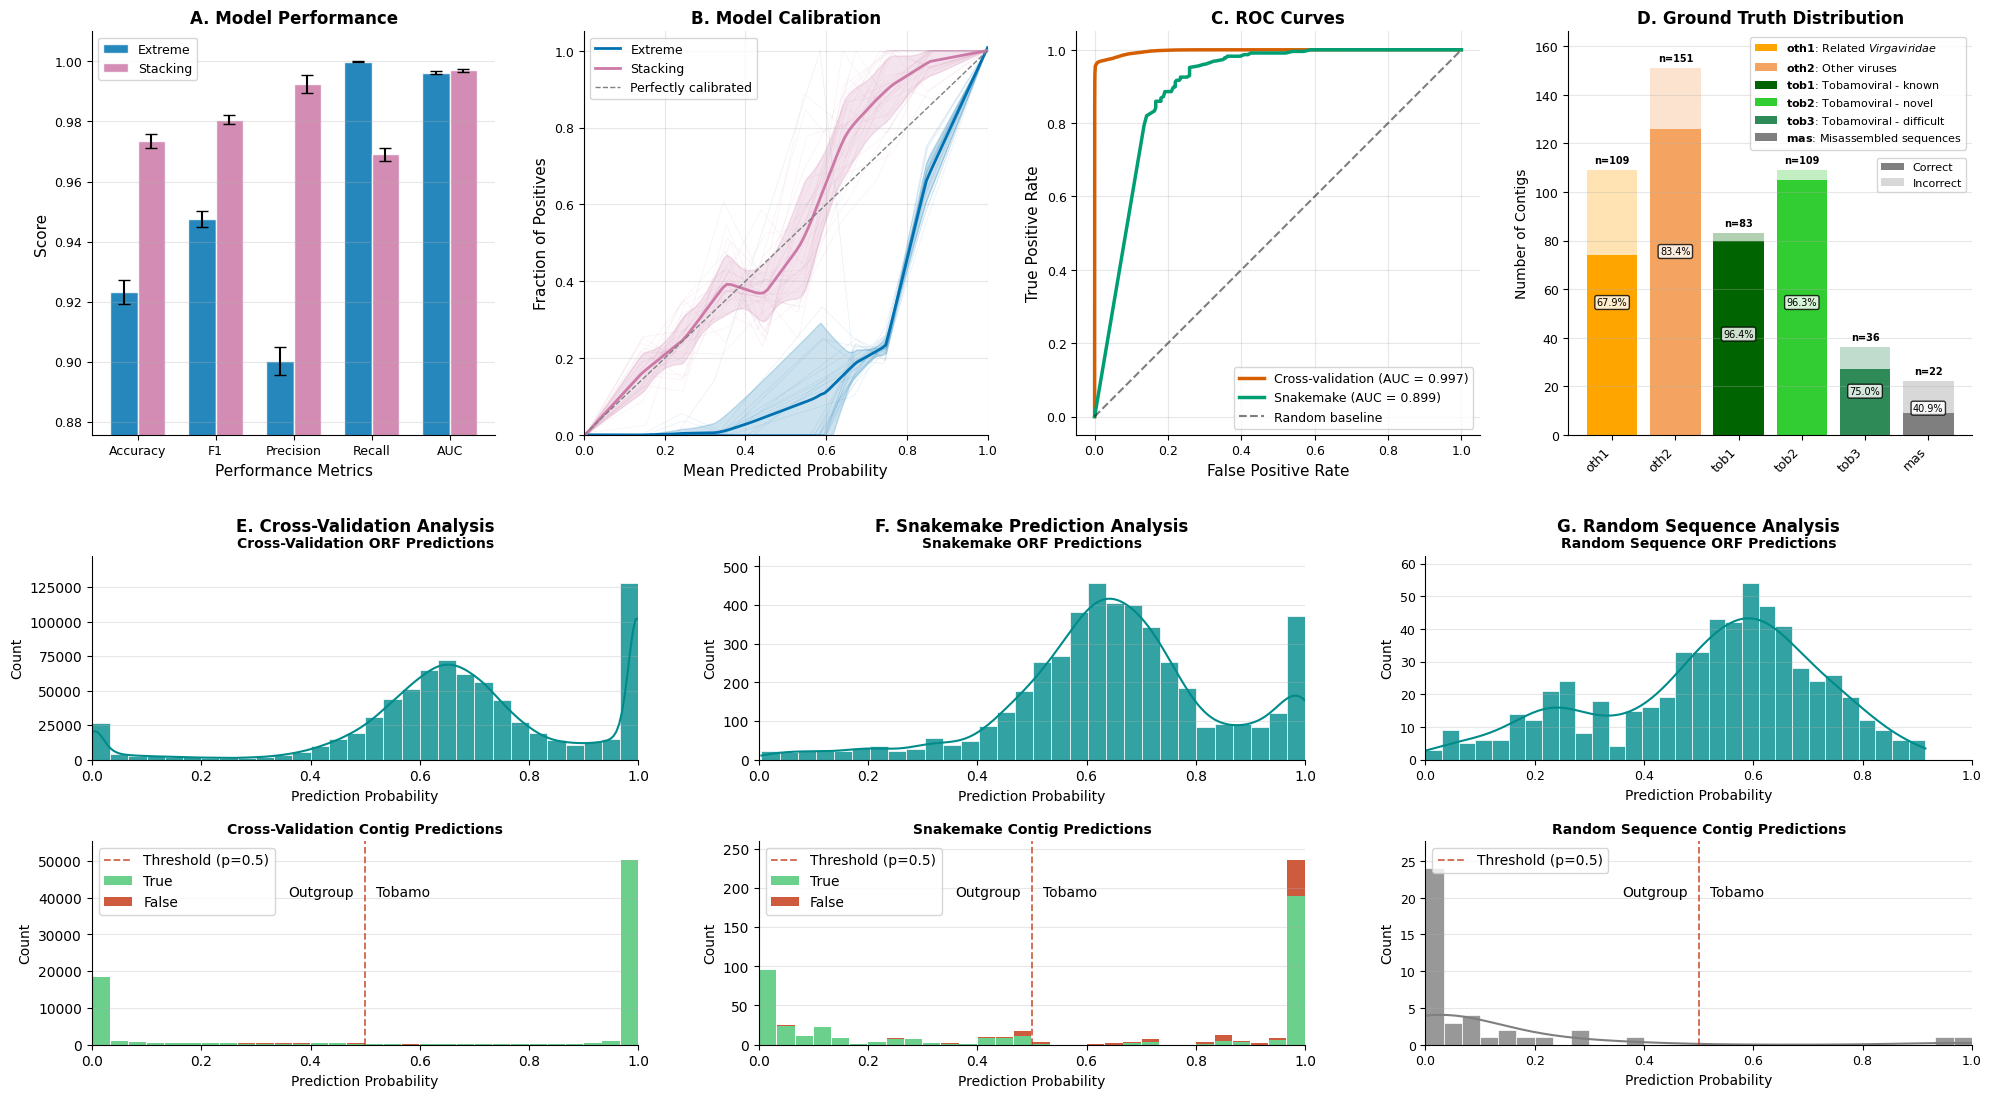

In [12]:
# NEW PANEL (ADDED AT END) - 4-over-3 layout
# Row 1: A model performance, B model calibration, C ROC curves, D Ground truth distribution
# Row 2: E cross-validation, F snakemake prediction, G random sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, roc_auc_score
from scipy.interpolate import interp1d

# ------------------------------------------------------------------
# Paths and data loading (self-standing)
# ------------------------------------------------------------------
base_dir = Path('/home/tobamo/analize/project-tobamo/analysis/model')
results_dir = base_dir / 'results'
evaluation_dir = results_dir / 'evaluation_results_fixed05'

# Evaluation outputs
method_comparison = pd.read_csv(evaluation_dir / 'method_comparison_stats.csv')
extreme_predictions = pd.read_csv(evaluation_dir / 'extreme_predictions_results.csv')
histogram_predictions = pd.read_csv(evaluation_dir / 'stacking_predictions_results.csv')
df_cal = pd.concat([extreme_predictions, histogram_predictions], ignore_index=True)

# Cross-validation hist data
histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/stacking_predictions_results.csv')
orf_histogram_cv = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/evaluation_results_fixed05/orf_predictions_results.csv')

# Random-sequence prediction data
orf_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/orf_predictions.csv',
    index_col=0
)
contigs_random_predictions = pd.read_csv(
    '/home/tobamo/analize/project-tobamo/analysis/model/results/random_seq/predictions/contig_predictions.csv',
    index_col=0
)

# Snakemake prediction data
snakemake_orf_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/orf_predictions.csv')
snakemake_contig_predictions = pd.read_csv('/home/tobamo/analize/project-tobamo/analysis/model/results/snakemake/predictions/contig_predictions.csv')

# Ground truth + snakemake contigs (for GT distribution + GT ROC)
gt = pd.read_excel('/home/tobamo/analize/project-tobamo/analysis/data/domain_sci_input/ground_truth_final_added_categories.xlsx')
gt.columns = gt.columns.str.strip()
df_gt = pd.merge(gt, snakemake_contig_predictions, on='contig_name', how='inner').copy()
df_gt['category'] = df_gt['category'].astype(str)
df_gt['prob_1'] = df_gt['prob_1'].astype(float)
if 'predicted_class' not in df_gt.columns:
    df_gt['predicted_class'] = (df_gt['prob_1'] >= 0.5).astype(int)
tobamo_categories = ['tob1', 'tob2', 'tob3']
df_gt['gt_binary'] = df_gt['category'].isin(tobamo_categories).astype(int)

# ------------------------------------------------------------------
# Shared style/config
# ------------------------------------------------------------------
plt.style.use('default')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

colors_ab = ['#0072B2', '#CC79A7']
colors_cd = ['#008B8B', '#50C878']
colors_roc = {'cv': '#D55E00', 'gt': '#009E73'}

category_palette = {
    'tob1': '#006400',
    'tob2': '#32CD32',
    'tob3': '#2E8B57',
    'oth1': '#FFA500',
    'oth2': '#F4A460',
    'oth3': '#CD853F',
    'mas': '#7F7F7F',
}

category_map = {
    'tob1': 'Tobamoviral - known',
    'tob2': 'Tobamoviral - novel',
    'tob3': 'Tobamoviral - difficult',
    'oth1': r'Related $\it{Virgaviridae}$',
    'oth2': 'Other viruses',
    'mas': 'Misassembled sequences',
}

custom_order = ['tob1', 'tob2', 'tob3', 'oth1', 'oth2', 'oth3', 'mas']

comparison_methods = method_comparison['method'].values
actual_methods = df_cal['mc_name'].unique()

method_mapping = {}
for comp_method in comparison_methods:
    if comp_method == 'extreme':
        if 'most_extreme' in actual_methods:
            method_mapping[comp_method] = 'most_extreme'
        elif 'extreme' in actual_methods:
            method_mapping[comp_method] = 'extreme'
    else:
        method_mapping[comp_method] = comp_method

method_colors = {}
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_colors[comp_method] = colors_ab[i]
    method_colors[actual_method] = colors_ab[i]

# Ground truth category stats for panel D
df_gt_panel = df_gt.copy()
df_gt_panel['correct'] = (df_gt_panel['predicted_class'].astype(int) == df_gt_panel['gt_binary'].astype(int)).astype(int)
cat_stats_df = (
    df_gt_panel
    .groupby('category', as_index=False)
    .agg(total_count=('category', 'size'), correct_count=('correct', 'sum'))
)
cat_stats_df['incorrect_count'] = cat_stats_df['total_count'] - cat_stats_df['correct_count']
cat_stats_df['accuracy'] = cat_stats_df['correct_count'] / cat_stats_df['total_count']
cat_stats_df['order'] = cat_stats_df['category'].map({cat: i for i, cat in enumerate(custom_order)}).fillna(999)
cat_stats_df = cat_stats_df.sort_values(['order', 'total_count']).reset_index(drop=True)

# ------------------------------------------------------------------
# Figure layout: nested 4-over-3 (tight, non-aligned columns)
# ------------------------------------------------------------------
fig = plt.figure(figsize=(20, 12))
gs_outer = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.16)
gs_top = gs_outer[0].subgridspec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.22)
gs_bottom = gs_outer[1].subgridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.22)

# A. Model performance
ax_a = fig.add_subplot(gs_top[0, 0])
metrics = ['accuracy', 'f1', 'precision', 'recall', 'auc']
metric_labels = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
x = np.arange(len(metrics))
width = 0.35
bar_positions = [x - width / 2, x + width / 2]

for i, comp_method in enumerate(comparison_methods):
    means = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_mean'].iloc[0] for metric in metrics]
    stds = [method_comparison.loc[method_comparison['method'] == comp_method, f'{metric}_std'].iloc[0] for metric in metrics]
    display_method = 'stacking' if comp_method == 'histogram' else comp_method
    ax_a.bar(
        bar_positions[i], means, width, yerr=stds, capsize=4,
        label=display_method.capitalize(), alpha=0.85,
        color=method_colors[comp_method], edgecolor='white', linewidth=1.0
    )

ax_a.set_xticks(x)
ax_a.set_xticklabels(metric_labels)
ax_a.set_xlabel('Performance Metrics')
ax_a.set_ylabel('Score')
min_vals = [method_comparison[f'{m}_mean'].min() - method_comparison[f'{m}_std'].max() for m in metrics]
y_min = max(0.85, min(min_vals) - 0.02)
ax_a.set_ylim(y_min, 1.01)
ax_a.grid(axis='y', alpha=0.3)
ax_a.set_title('A. Model Performance', fontweight='bold')
ax_a.legend(loc='upper left', frameon=True)
ax_a.set_box_aspect(1)

# B. Model calibration (square)
ax_b = fig.add_subplot(gs_top[0, 1])
for i, comp_method in enumerate(comparison_methods):
    actual_method = method_mapping.get(comp_method, comp_method)
    method_data = df_cal[df_cal['mc_name'] == actual_method]
    if len(method_data) == 0:
        continue

    prob_true_values = []
    prob_pred_values = []
    iterations = method_data['iteration'].unique() if 'iteration' in method_data.columns else [0]

    for iteration in iterations:
        iter_data = method_data[method_data['iteration'] == iteration] if 'iteration' in method_data.columns else method_data
        if len(iter_data) == 0:
            continue

        y_true = iter_data['ground_truth']
        y_scores = iter_data['prob_1']
        if len(y_true) > 10 and len(np.unique(y_true)) > 1:
            prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
            ax_b.plot(prob_pred, prob_true, color=method_colors[comp_method], alpha=0.1, lw=0.5)
            prob_true_values.append(prob_true)
            prob_pred_values.append(prob_pred)

    if prob_true_values:
        x_interp = np.linspace(0, 1, 100)
        interp_curves = []
        for prob_true, prob_pred in zip(prob_true_values, prob_pred_values):
            if len(prob_pred) > 1:
                interp_func = interp1d(prob_pred, prob_true, bounds_error=False, fill_value='extrapolate')
                interp_curves.append(interp_func(x_interp))

        if interp_curves:
            interp_array = np.array(interp_curves)
            mean_curve = np.nanmean(interp_array, axis=0)
            std_curve = np.nanstd(interp_array, axis=0)
            display_method = 'stacking' if comp_method == 'histogram' else comp_method
            ax_b.plot(x_interp, mean_curve, color=method_colors[comp_method], lw=2, label=display_method.capitalize())
            ax_b.fill_between(
                x_interp,
                np.maximum(0, mean_curve - std_curve),
                np.minimum(1, mean_curve + std_curve),
                color=method_colors[comp_method],
                alpha=0.2,
            )

ax_b.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfectly calibrated')
ax_b.set_xlim(0, 1)
ax_b.set_ylim(0, 1.05)
ax_b.set_xlabel('Mean Predicted Probability')
ax_b.set_ylabel('Fraction of Positives')
ax_b.grid(True, alpha=0.3)
ax_b.set_title('B. Model Calibration', fontweight='bold')
ax_b.legend(loc='upper left', frameon=True)
ax_b.set_box_aspect(1)

# C. ROC curves (square)
ax_c = fig.add_subplot(gs_top[0, 2])

y_true_cv = histogram_cv['ground_truth'].astype(int)
y_scores_cv = histogram_cv['prob_1'].astype(float)
auc_cv = roc_auc_score(y_true_cv, y_scores_cv)
thresholds = np.linspace(0, 1, 101)
fpr_cv, tpr_cv = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_cv >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_cv, pred_thresh).ravel()
    fpr_cv.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_cv.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

y_true_gt = df_gt['gt_binary'].astype(int)
y_scores_gt = df_gt['prob_1'].astype(float)
auc_gt = roc_auc_score(y_true_gt, y_scores_gt)
fpr_gt, tpr_gt = [], []
for threshold in thresholds:
    pred_thresh = (y_scores_gt >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_gt, pred_thresh).ravel()
    fpr_gt.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    tpr_gt.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

ax_c.plot(fpr_cv, tpr_cv, linewidth=2.5, color=colors_roc['cv'], label=f'Cross-validation (AUC = {auc_cv:.3f})')
ax_c.plot(fpr_gt, tpr_gt, linewidth=2.5, color=colors_roc['gt'], label=f'Snakemake (AUC = {auc_gt:.3f})')
ax_c.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
ax_c.set_xlabel('False Positive Rate')
ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C. ROC Curves', fontweight='bold')
ax_c.grid(True, alpha=0.3)
ax_c.legend(loc='lower right', frameon=True)
ax_c.set_box_aspect(1)

# D. Ground truth distribution (vertical histogram)
ax_d = fig.add_subplot(gs_top[0, 3])
# ax_d.set_box_aspect(1.6)

panel_d_order = ['oth1', 'oth2', 'tob1', 'tob2', 'tob3', 'mas']
cat_stats_d = cat_stats_df[cat_stats_df['category'].isin(panel_d_order)].copy()
cat_stats_d['plot_order'] = cat_stats_d['category'].map({cat: i for i, cat in enumerate(panel_d_order)})
cat_stats_d = cat_stats_d.sort_values('plot_order').reset_index(drop=True)

x_positions = np.arange(len(cat_stats_d))
correct_vals = cat_stats_d['correct_count'].values
incorrect_vals = cat_stats_d['incorrect_count'].values
bar_colors = [category_palette.get(cat, '#999999') for cat in cat_stats_d['category']]

ax_d.bar(x_positions, correct_vals, color=bar_colors, alpha=1.0)
ax_d.bar(x_positions, incorrect_vals, bottom=correct_vals, color=bar_colors, alpha=0.3)

ax_d.set_xticks(x_positions)
ax_d.set_xticklabels(cat_stats_d['category'], rotation=45, ha='right')
ax_d.set_ylabel('Number of Contigs', fontsize=10)
ax_d.set_title('D. Ground Truth Distribution', fontsize=12, fontweight='bold')
ax_d.tick_params(axis='both', which='major', labelsize=9)
ax_d.set_box_aspect(1)

for i, (_, row) in enumerate(cat_stats_d.iterrows()):
    total = row['total_count']
    ax_d.text(i, total + 2, f"n={total}", ha='center', va='bottom', fontweight='bold', fontsize=7)
    ax_d.text(
        i,
        max(total * 0.5, 0.8),
        f"{row['accuracy']:.1%}",
        va='center',
        ha='center',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8)
    )

if len(cat_stats_d) > 0:
    ax_d.set_ylim(0, cat_stats_d['total_count'].max() * 1.1)
ax_d.grid(True, axis='y', alpha=0.3)

legend_handles = []
for cat in panel_d_order:
    if cat in cat_stats_d['category'].values:
        patch = plt.Rectangle((0, 0), 1, 1, fc=category_palette.get(cat, '#999999'))
        legend_handles.append((patch, rf"$\bf{{{cat}}}$: {category_map.get(cat, cat)}"))
if legend_handles:
    patches, labels = zip(*legend_handles)
    category_legend = ax_d.legend(
        patches,
        labels,
        loc='upper right',
        fontsize=8,
        ncol=1,
        frameon=True,
    )
    ax_d.add_artist(category_legend)

legend_elements_accuracy = [
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=1.0, label='Correct'),
    plt.Rectangle((0, 0), 1, 1, facecolor='gray', alpha=0.3, label='Incorrect')
]

# Place second legend below the upper-right category legend
ax_d.legend(
    handles=legend_elements_accuracy,
    loc='upper right',
    bbox_to_anchor=(1.0, 0.7),  # lower this value to move further down
    fontsize=8,
    frameon=True,
)

# E. Cross-validation
ax_e = fig.add_subplot(gs_bottom[0, 0])
gs_e = ax_e.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_e1 = fig.add_subplot(gs_e[0])
ax_e2 = fig.add_subplot(gs_e[1])

sns.histplot(data=orf_histogram_cv, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_e1, edgecolor='white', linewidth=0.5)
max_height = ax_e1.get_ylim()[1]
ax_e1.set_ylim(0, max_height * 1.1)
ax_e1.set_title('Cross-Validation ORF Predictions', fontsize=10, fontweight='bold')
ax_e1.set_xlabel('Prediction Probability', fontsize=10)
ax_e1.set_ylabel('Count', fontsize=10)
ax_e1.grid(axis='y', alpha=0.3)

cv_contig_eval = histogram_cv.copy()
cv_contig_eval['predicted_class'] = (cv_contig_eval['prob_1'] >= 0.5).astype(int)
cv_contig_eval['is_correct'] = (cv_contig_eval['predicted_class'] == cv_contig_eval['ground_truth'].astype(int))
bins = np.linspace(0, 1, 31)
true_vals = cv_contig_eval.loc[cv_contig_eval['is_correct'], 'prob_1'].astype(float)
false_vals = cv_contig_eval.loc[~cv_contig_eval['is_correct'], 'prob_1'].astype(float)
true_hist, _ = np.histogram(true_vals, bins=bins)
false_hist, _ = np.histogram(false_vals, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = (bins[1] - bins[0]) * 0.95
ax_e2.bar(bin_centers, true_hist, width=bin_width, color=colors_cd[1], alpha=0.85, label='True')
ax_e2.bar(bin_centers, false_hist, width=bin_width, bottom=true_hist, color='#C73E1D', alpha=0.85, label='False')
max_height = max(1, np.max(true_hist + false_hist))
ax_e2.set_ylim(0, max_height * 1.1)
ax_e2.set_title('Cross-Validation Contig Predictions', fontsize=10, fontweight='bold')
ax_e2.set_xlabel('Prediction Probability', fontsize=10)
ax_e2.set_ylabel('Count', fontsize=10)
ax_e2.grid(axis='y', alpha=0.3)
ax_e2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_e2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_e2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_e2.legend(loc='upper left', fontsize=10, frameon=True)

for ax in [ax_e1, ax_e2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=10)

ax_e.set_frame_on(False)
ax_e.set_xticks([])
ax_e.set_yticks([])
ax_e.set_title('E. Cross-Validation Analysis', fontsize=12, pad=18, fontweight='bold')

# F. Snakemake prediction
ax_f = fig.add_subplot(gs_bottom[0, 1])
gs_f = ax_f.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_f1 = fig.add_subplot(gs_f[0])
ax_f2 = fig.add_subplot(gs_f[1])

sns.histplot(data=snakemake_orf_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_f1, edgecolor='white', linewidth=0.5)
max_height = ax_f1.get_ylim()[1]
ax_f1.set_ylim(0, max_height * 1.1)
ax_f1.set_title('Snakemake ORF Predictions', fontsize=10, fontweight='bold')
ax_f1.set_ylabel('Count', fontsize=10)
ax_f1.set_xlabel('Prediction Probability', fontsize=10)
ax_f1.grid(axis='y', alpha=0.3)

snakemake_contig_eval = df_gt.copy()
if 'predicted_class' not in snakemake_contig_eval.columns:
    snakemake_contig_eval['predicted_class'] = (snakemake_contig_eval['prob_1'] >= 0.5).astype(int)
snakemake_contig_eval['is_correct'] = (snakemake_contig_eval['predicted_class'].astype(int) == snakemake_contig_eval['gt_binary'].astype(int))
bins = np.linspace(0, 1, 31)
true_vals = snakemake_contig_eval.loc[snakemake_contig_eval['is_correct'], 'prob_1'].astype(float)
false_vals = snakemake_contig_eval.loc[~snakemake_contig_eval['is_correct'], 'prob_1'].astype(float)
true_hist, _ = np.histogram(true_vals, bins=bins)
false_hist, _ = np.histogram(false_vals, bins=bins)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = (bins[1] - bins[0]) * 0.95
ax_f2.bar(bin_centers, true_hist, width=bin_width, color=colors_cd[1], alpha=0.85, label='True')
ax_f2.bar(bin_centers, false_hist, width=bin_width, bottom=true_hist, color='#C73E1D', alpha=0.85, label='False')
max_height = max(1, np.max(true_hist + false_hist))
ax_f2.set_ylim(0, max_height * 1.1)
ax_f2.set_title('Snakemake Contig Predictions', fontsize=10, fontweight='bold')
ax_f2.set_xlabel('Prediction Probability', fontsize=10)
ax_f2.set_ylabel('Count', fontsize=10)
ax_f2.grid(axis='y', alpha=0.3)
ax_f2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_f2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_f2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_f2.legend(loc='upper left', fontsize=10, frameon=True)

for ax in [ax_f1, ax_f2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=10)

ax_f.set_frame_on(False)
ax_f.set_xticks([])
ax_f.set_yticks([])
ax_f.set_title('F. Snakemake Prediction Analysis', fontsize=12, pad=18, fontweight='bold')

# G. Random sequence
ax_g = fig.add_subplot(gs_bottom[0, 2])
gs_g = ax_g.get_subplotspec().subgridspec(2, 1, hspace=0.4)
ax_g1 = fig.add_subplot(gs_g[0])
ax_g2 = fig.add_subplot(gs_g[1])

sns.histplot(data=orf_random_predictions, x='prob_1', bins=30, kde=True, color=colors_cd[0], alpha=0.8, ax=ax_g1, edgecolor='white', linewidth=0.5)
max_height = ax_g1.get_ylim()[1]
ax_g1.set_ylim(0, max_height * 1.1)
ax_g1.set_title('Random Sequence ORF Predictions', fontsize=10, fontweight='bold')
ax_g1.set_xlabel('Prediction Probability', fontsize=10)
ax_g1.set_ylabel('Count', fontsize=10)
ax_g1.grid(axis='y', alpha=0.3)

sns.histplot(data=contigs_random_predictions, x='prob_1', bins=30, kde=True, color='#7F7F7F', alpha=0.8, ax=ax_g2, edgecolor='white', linewidth=0.5)
max_height = ax_g2.get_ylim()[1]
ax_g2.set_ylim(0, max_height * 1.1)
ax_g2.set_title('Random Sequence Contig Predictions', fontsize=10, fontweight='bold')
ax_g2.set_xlabel('Prediction Probability', fontsize=10)
ax_g2.set_ylabel('Count', fontsize=10)
ax_g2.grid(axis='y', alpha=0.3)
ax_g2.axvline(x=0.5, color='#C73E1D', linestyle='--', linewidth=1.3, alpha=0.8, label='Threshold (p=0.5)')
ax_g2.text(0.52, max_height * 0.8, 'Tobamo', fontsize=10)
ax_g2.text(0.48, max_height * 0.8, 'Outgroup', fontsize=10, ha='right')
ax_g2.legend(loc='upper left', fontsize=10, frameon=True)

for ax in [ax_g1, ax_g2]:
    ax.set_xlim(0, 1)
    ax.tick_params(axis='both', labelsize=9)

ax_g.set_frame_on(False)
ax_g.set_xticks([])
ax_g.set_yticks([])
ax_g.set_title('G. Random Sequence Analysis', fontsize=12, pad=18, fontweight='bold')

plt.subplots_adjust(right=0.985, left=0.045, bottom=0.08, top=0.96)

# plt.savefig(figures_dir / 'main_fig2.png', dpi=300, bbox_inches='tight', 
#            facecolor='white', edgecolor='none')

plt.show()